# Clase 8: Movimiento Geométrico Browniano

[]()

El movimiento geométrico browniano (GBM, por sus siglas en inglés) es uno de los modelos más utilizados en finanzas cuantitativas para describir la evolución de precios de activos a lo largo del tiempo. Se emplea ampliamente en la simulación de escenarios futuros, en la valuación de derivados y en la medición de riesgo.

El modelo se define mediante la ecuación diferencial estocástica:

$dS_t = \mu S_t \space dt + \sigma S_t \space dW_t$

Esta ecuación describe cómo cambia el precio ($S_t$) en un intervalo infinitesimal de tiempo. Cada término tiene una interpretación específica:1

- $S_t$: precio del activo en el tiempo t
- $μ$: tasa de crecimiento esperada del precio
- $σ$: volatilidad del activo
- $dW_t$: incremento de un movimiento browniano

La ecuación puede interpretarse como la suma de dos componentes:

### Componente determinista

$\mu S_t \space dt$

Representa el crecimiento esperado del precio en un intervalo pequeño de tiempo. Este término implica que el crecimiento del precio es proporcional a su nivel actual. En otras palabras, el modelo supone que los activos crecen de manera compuesta.

### Componente aleatorio

$\sigma S_t \space dW_t$

Representa la parte aleatoria del cambio en el precio. Este término incorpora la incertidumbre del mercado. 

La presencia del factor ($S_t$) implica que la magnitud de las fluctuaciones depende del nivel del precio. O sea, activos de mayor valor suelen experimentar cambios absolutos mayores que activos de menor valor.

### Solución del modelo

La ecuación diferencial anterior tiene como solución:

$S_t = S_0 \exp\left((\mu - \tfrac{1}{2}\sigma^2)t + \sigma W_t\right)$

Esta expresión describe directamente el precio en el tiempo t. 

Que tenga forma exponencial tiene varias consecuencias importantes para finanzas:

1. El precio siempre es positivo.
2. El crecimiento es compuesto.
3. La volatilidad afecta de manera multiplicativa.
4. El logaritmo del precio sigue una distribución normal.

Estas propiedades hacen del movimiento geométrico browniano un modelo adecuado para representar precios financieros.

## 2. En finanzas

El modelo de movimiento geométrico browniano se fundamenta en la idea de que los precios financieros evolucionan de forma proporcional y no aditiva. Esto significa que lo relevante en el modelo no son los cambios absolutos, sino los cambios porcentuales.

### 2.1 Cambios porcentuales del precio

Si se divide la ecuación del modelo entre ($S_t$), se obtiene:

$\frac{dS_t}{S_t} = \mu dt + \sigma dW_t$

Esta expresión muestra que el cambio relativo del precio (en otras palabras *retorno instantáneo*) está compuesto por:

- Un componente promedio: μ
- Un componente aleatorio: $σ dW_t$

Esto implica que los retornos del activo son aleatorios y siguen una dinámica basada en movimiento browniano.

> El modelo asume que los retornos porcentuales son aleatorios, mientras que el precio se ajusta de manera multiplicativa.
> 

---

### 2.2 Retornos logarítmicos

El modelo implica que el logaritmo del precio sigue una distribución normal:

$\ln(S_t) \sim N(\text{media}, \text{varianza})$

Más específicamente:

$\ln\left(\frac{S_t}{S_0}\right)$

sigue una distribución normal con:

- Media proporcional al tiempo
- Varianza proporcional al tiempo

Esto es consistente con el uso de retornos logarítmicos en finanzas, ya que estos permiten modelar el crecimiento compuesto de manera aditiva en el tiempo.

En particular, si

$S_t = S_0 \exp\left((\mu - \tfrac{1}{2}\sigma^2)t + \sigma W_t\right)$

Entonces:

$ln (S_t) = ln (S_0)+[(μ − \frac{1}{2} σ^2)t+σWt]$

Eso implica que 

$ln(S_t)∼N$

### 2.3 Rol de la volatilidad

El parámetro σ controla la magnitud de las fluctuaciones del precio.

- σ alto implica mayor incertidumbre
- σ bajo implica mayor estabilidad
- σ determina la dispersión de posibles precios futuros

En horizontes temporales cortos, la volatilidad domina la dinámica del precio.

En horizontes largos, tanto el drift $μ$ como la volatilidad influyen en la distribución final.

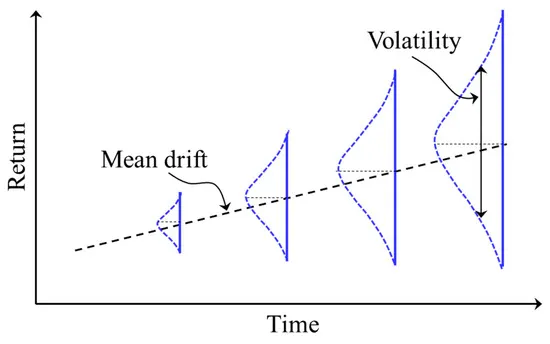

### 2.4 Interpretación probabilística

El modelo no produce un precio único para el futuro, sino una distribución de posibles precios. Cada trayectoria simulada representa un escenario posible. La dispersión entre trayectorias refleja la incertidumbre del mercado.

Este enfoque probabilístico permite:

- Analizar riesgo
- Estimar probabilidades de pérdida
- Calcular percentiles
- Evaluar escenarios extremos

Por esta razón, el movimiento geométrico browniano se utiliza como base para simulaciones Monte Carlo en finanzas.

### 2.5 Limitaciones y alcance del modelo

El movimiento geométrico browniano es un modelo simplificado. Aunque captura varios aspectos fundamentales de la dinámica de precios, no incorpora todos los fenómenos observados en mercados reales, como saltos bruscos (cisnes negros) o cambios en la volatilidad.

# 3. Discretización para simulación

Aunque el modelo es continuo, su implementación computacional se realiza en tiempo discreto. 

Recordando la forma continua:

$S_t = S_0 \exp\left((\mu - \tfrac{1}{2}\sigma^2)t + \sigma W_t\right)$

**La forma exacta de simulación es:**

$S_{t+\Delta t} = S_t \exp\left((\mu - \tfrac{1}{2}\sigma^2)\Delta t + \sigma\sqrt{\Delta t} \space \epsilon\right)$

donde:

$\epsilon \sim N(0,1)$

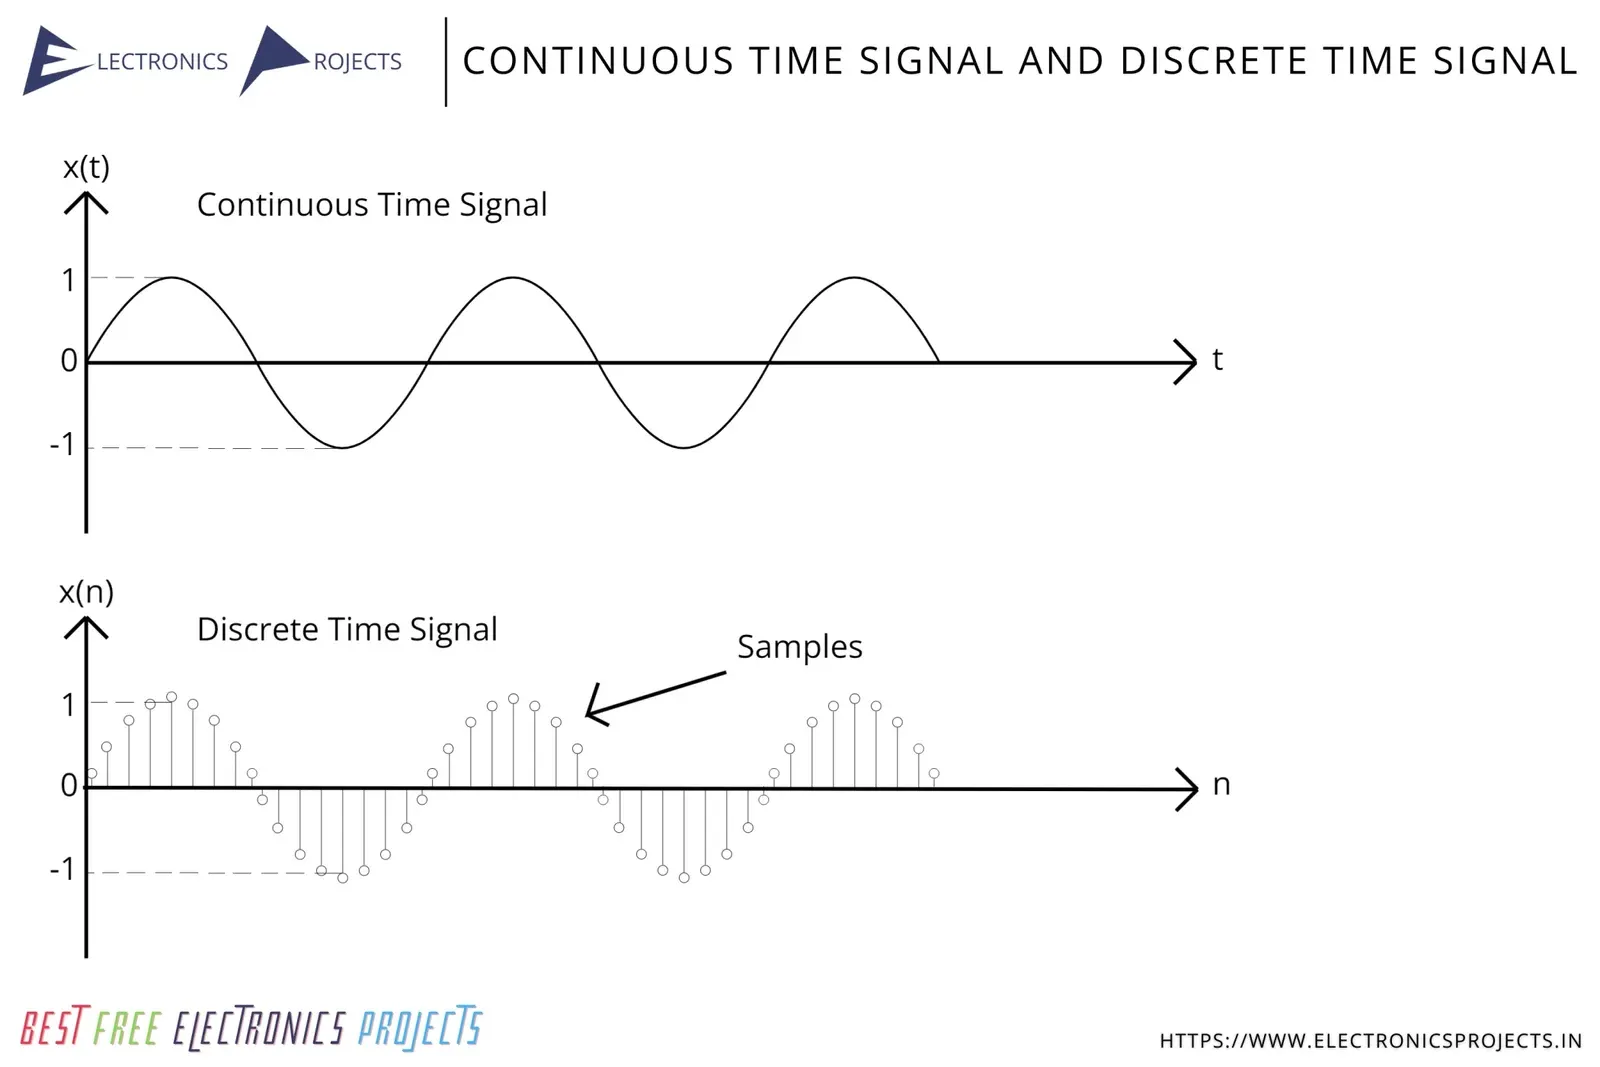

# 4. Simulación de una trayectoria individual

Implementar una trayectoria permite observar el comportamiento básico del modelo.

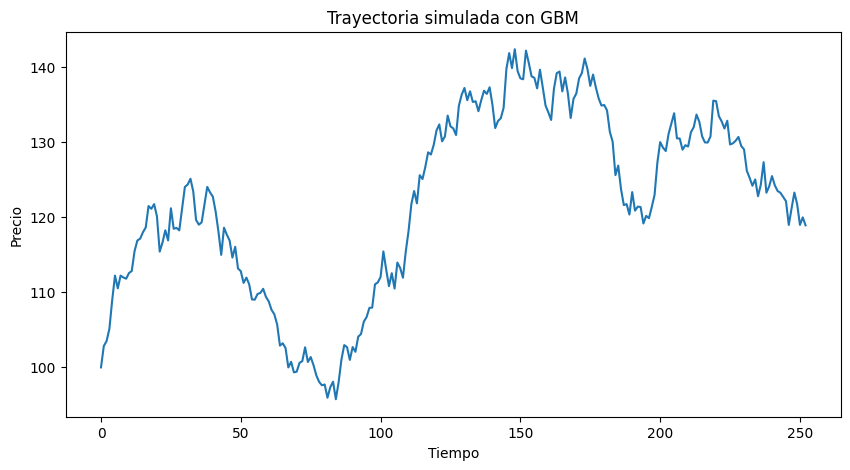

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

S0 = 100
mu = 0.08
sigma = 0.25
T = 1
n = 252
dt = T/n

prices = [S0]

for _ in range(n):
    epsilon = np.random.normal(0,1)
    St = prices[-1] * np.exp((mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*epsilon)
    prices.append(St)

plt.figure(figsize=(10,5))
plt.plot(prices)
plt.title("Trayectoria simulada con GBM")
plt.xlabel("Tiempo")
plt.ylabel("Precio")
plt.show()

# 5. Múltiples trayectorias y dispersión temporal

Simular múltiples trayectorias permite visualizar la incertidumbre futura.

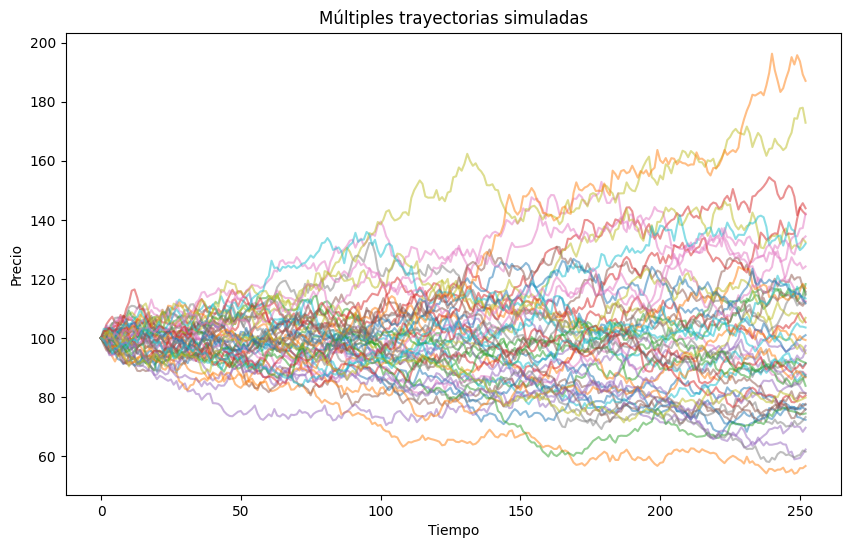

In [2]:
plt.figure(figsize=(10,6))

for _ in range(50):
    prices = [S0]
    for _ in range(n):
        epsilon = np.random.normal(0,1)
        St = prices[-1] * np.exp((mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*epsilon)
        prices.append(St)
    plt.plot(prices, alpha=0.5)

plt.title("Múltiples trayectorias simuladas")
plt.xlabel("Tiempo")
plt.ylabel("Precio")
plt.show()

Puedes ver que a medida que aumenta el tiempo:

- La dispersión entre trayectorias crece
- La incertidumbre sobre el precio futuro aumenta
- El modelo genera un abanico de posibles escenarios

# 6. Efecto de la volatilidad

La volatilidad controla la dispersión de las trayectorias.

Simular trayectorias con distintos valores de σ.

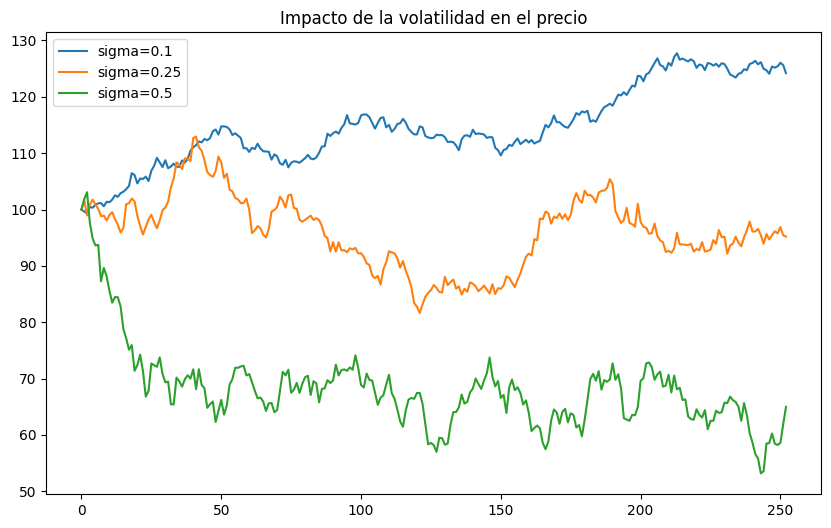

In [3]:
sigmas = [0.1, 0.25, 0.5]

plt.figure(figsize=(10,6))

for sigma in sigmas:
    prices = [S0]
    for _ in range(n):
        epsilon = np.random.normal(0,1)
        St = prices[-1] * np.exp((mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*epsilon)
        prices.append(St)
    plt.plot(prices, label=f"sigma={sigma}")

plt.legend()
plt.title("Impacto de la volatilidad en el precio")
plt.show()

### Observaciones

- Mayor volatilidad implica mayor dispersión
- El rango de precios posibles se amplía
- El riesgo asociado aumenta

---

# 7. Efecto del drift

El parámetro $μ$ controla el crecimiento promedio del precio.

Simular trayectorias con distintos valores de $μ$ manteniendo $σ$ constante.


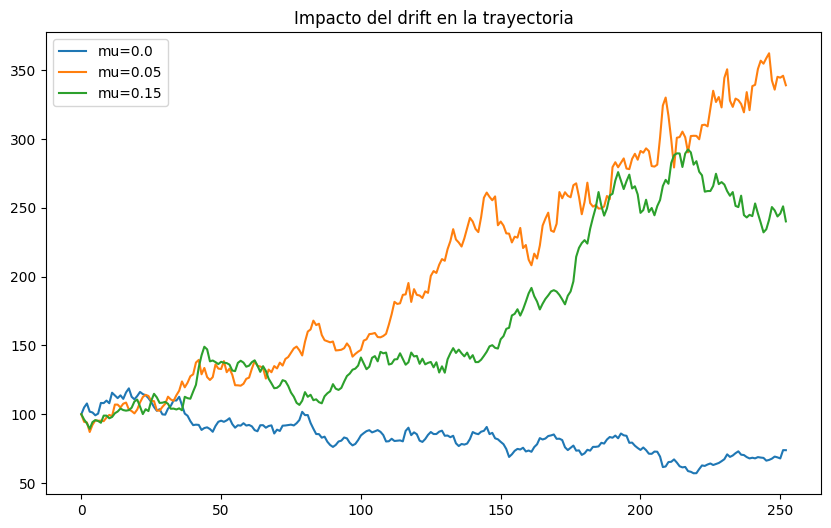

In [4]:
mus = [0.0, 0.05, 0.15]

plt.figure(figsize=(10,6))

for mu in mus:
    prices = [S0]
    for _ in range(n):
        epsilon = np.random.normal(0,1)
        St = prices[-1] * np.exp((mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*epsilon)
        prices.append(St)
    plt.plot(prices, label=f"mu={mu}")

plt.legend()
plt.title("Impacto del drift en la trayectoria")
plt.show()

### Interpretación

- μ afecta la tendencia de largo plazo
- σ domina en horizontes cortos
- μ domina en horizontes largos

# 8. Distribución del precio final

El análisis de muchas simulaciones permite estudiar la distribución futura del precio.

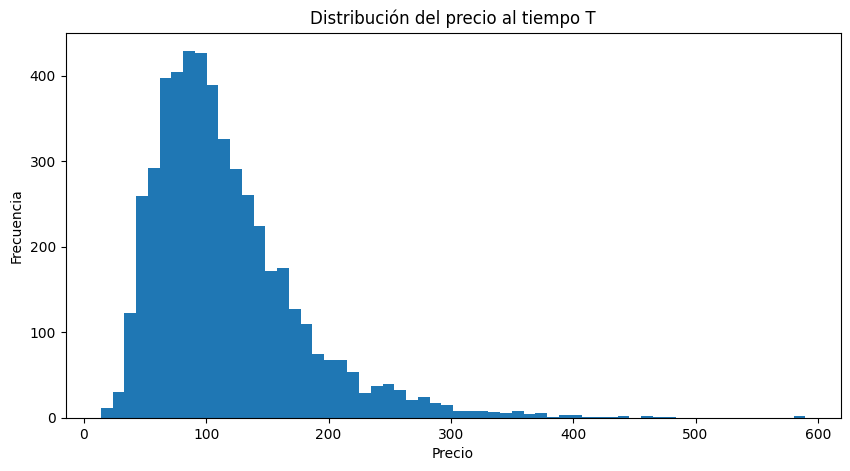

In [5]:
n_sim = 5000
final_prices = []

for _ in range(n_sim):
    price = S0
    for _ in range(n):
        epsilon = np.random.normal(0,1)
        price *= np.exp((mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*epsilon)
    final_prices.append(price)

plt.figure(figsize=(10,5))
plt.hist(final_prices, bins=60)
plt.title("Distribución del precio al tiempo T")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()

### Observaciones

- La distribución es asimétrica
- Existe cola derecha larga
- El precio nunca es negativo
- La media no coincide con la mediana

Esto refleja la naturaleza lognormal del modelo.

---

# 9. Distribución de retornos

Analizar la distribución de retornos porcentuales finales. $T$ vs $S_0$

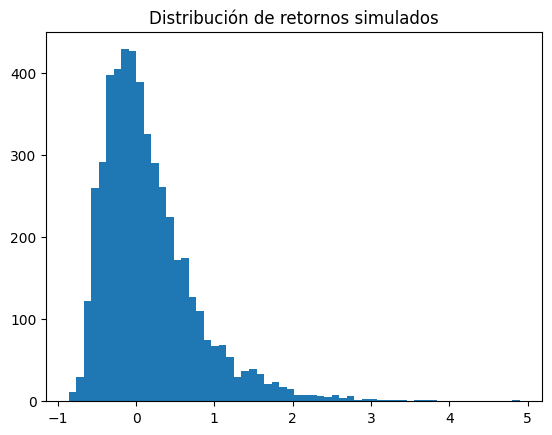

In [6]:
returns = [(p/S0 - 1) for p in final_prices]

plt.hist(returns, bins=60)
plt.title("Distribución de retornos simulados")
plt.show()

Los retornos presentan dispersión dependiente de σ y horizonte temporal.

Retornos, todos.

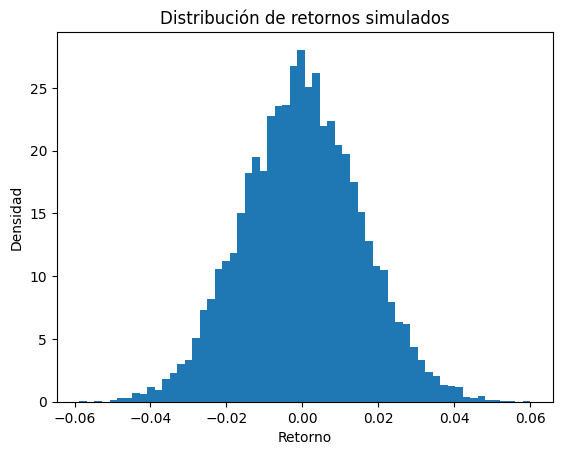

In [7]:
np.random.seed(0)

mu = 0.08
sigma = 0.25
T = 1
n = 252
dt = T/n

returns = []

for _ in range(10000):
    epsilon = np.random.normal(0,1)
    r = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*epsilon
    returns.append(r)

plt.hist(returns, bins=60, density=True)
plt.title("Distribución de retornos simulados")
plt.xlabel("Retorno")
plt.ylabel("Densidad")
plt.show()

# 10. Notas finales

Hemos observado que el movimiento geométrico browniano permite:

- Generar escenarios futuros de precios
- Analizar incertidumbre en distintos horizontes
- Evaluar impacto de volatilidad
- Estimar distribuciones de retornos
- Modelar dinámicas de crecimiento compuesto

Observamos el modelo teórico y como se afecta la simulación con los diferentes parámetros del modelo.